#SOLUTION OF PUI2015 Midterm exam


In [1]:
from __future__ import print_function
__author__ = 'fbb'
import numpy as np
import pandas as pd
import pylab as pl
import os
import json
import geopandas as gp
import urllib2
import statsmodels.api as sm1
import statsmodels.formula.api as sm

s = json.load( open(os.getenv ('PUI2015')+"/fbb_matplotlibrc.json") )
pl.rcParams.update(s)
pl.rcParams.update({'axes.titlesize': 'large'})
%pylab inline

Populating the interactive namespace from numpy and matplotlib


/Users/fbianco/Library/Enthought/Canopy_64bit/User/lib/python2.7/site-packages/matplotlib/__init__.py:855: UserWarning: svg.embed_char_paths is deprecated and replaced with svg.fonttype; please use the latter.
  warnings.warn(self.msg_depr % (key, alt_key))


#GOAL: assess if a first or second degree polynomial fit to the number of residential units per Zip code is a reasonable predictor of the number of citibike rides originating from that zipcode

##OBVIOUS LIMITATIONS OF THIS ANALYSIS: predicting the rides by number of residential units does not take into account the availability of means of transportations in the area, or even the current availability of bikes in the area. 


##I am about to use only 2 months of data, in order to produce a quick analysis. More data, for a longer timeline, would certainly benefit the analysis. 


##The citibike stations accounted for in the way I am going to use the data (simply concatenating two files) may not have been there for all of the 2 months my investigation is spanning, and more stations in a ZipCode may have been added in the time between the two months of data I am using, or in the course of the second month, skeweing the analysis.


##Manhattan citibike users are likely to be commuters, to use the bike to move to and from work, and the trips that do not originate from the Zip Code of residence may skew the analysis, but notice that I am not trying to establish a direct (causal) link between bike readership and residence, just to assess how well the two correlate, and if the correlate in a simple way. Thus the presence of a large non-resident poulation would not matter, as long as the prediction I use are applied to a similar environment (i.e. restricted to Manhattan, since Manhattan as a very peculiar environment!)


##i will choose significance level of $\alpha=0.05$ for my statistical tests

Reading citibikes data from the URL link (for reproducibility)

In [2]:
dfall=[]
dfall.append(
    pd.read_csv(
        'http://cosmo.nyu.edu/~fb55/UI_CUSP_2015/data/201502-citibike-tripdata.csv'))
dfall.append(
    pd.read_csv(
        'http://cosmo.nyu.edu/~fb55/UI_CUSP_2015/data/201506-citibike-tripdata.csv'))

In [3]:
#checking that file got read ok
print (dfall[0].columns, dfall[1].columns)

Index([u'tripduration', u'starttime', u'stoptime', u'start station id',
       u'start station name', u'start station latitude',
       u'start station longitude', u'end station id', u'end station name',
       u'end station latitude', u'end station longitude', u'bikeid',
       u'usertype', u'birth year', u'gender'],
      dtype='object') Index([u'tripduration', u'starttime', u'stoptime', u'start station id',
       u'start station name', u'start station latitude',
       u'start station longitude', u'end station id', u'end station name',
       u'end station latitude', u'end station longitude', u'bikeid',
       u'usertype', u'birth year', u'gender'],
      dtype='object')


joining the data for 2 months into a single dataset (concatenating)

In [4]:
df=pd.concat(dfall)
#print df['start station id'].astype(int).min()
#print df['start station id'].astype(int).max()
df.columns

Index([u'tripduration', u'starttime', u'stoptime', u'start station id',
       u'start station name', u'start station latitude',
       u'start station longitude', u'end station id', u'end station name',
       u'end station latitude', u'end station longitude', u'bikeid',
       u'usertype', u'birth year', u'gender'],
      dtype='object')

In [5]:
df.head()

,tripduration,starttime,stoptime,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,end station longitude,bikeid,usertype,birth year,gender
0,801,2/1/2015 0:00,2/1/2015 0:14,521,8 Ave & W 31 St,40.750450,-73.994811,423,W 54 St & 9 Ave,40.765849,-73.986905,17131,Subscriber,1978,2
1,379,2/1/2015 0:00,2/1/2015 0:07,497,E 17 St & Broadway,40.737050,-73.990093,504,1 Ave & E 15 St,40.732219,-73.981656,21289,Subscriber,1993,1
2,2474,2/1/2015 0:01,2/1/2015 0:42,281,Grand Army Plaza & Central Park S,40.764397,-73.973715,127,Barrow St & Hudson St,40.731724,-74.006744,18903,Subscriber,1969,2
3,818,2/1/2015 0:01,2/1/2015 0:15,2004,6 Ave & Broome St,40.724399,-74.004704,505,6 Ave & W 33 St,40.749013,-73.988484,21044,Subscriber,1985,2
4,544,2/1/2015 0:01,2/1/2015 0:10,323,Lawrence St & Willoughby St,40.692362,-73.986317,83,Atlantic Ave & Fort Greene Pl,40.683826,-73.976323,19868,Subscriber,1957,1


In [6]:
bsize = gp.GeoDataFrame.from_file("../..//HW5/Manhattan/MNMapPLUTO.shp")


Reading in the file that contains the zip code per station id

In [7]:
this_url = "http://cosmo.nyu.edu/~fb55/UI_CUSP_2015/data/stationzips.json"
response = urllib2.urlopen(this_url)
sz = json.load(response)


In [8]:
#print sz
#the json file returns a dictionary with string keys (the station ids) 
#and integer values (the zip codes)
#trying conversions of the keys of the dictionary, these are just tests 
#so i am commenting them out
#print sz.keys()
#print np.array(sz.keys()).astype(float)

In [9]:
#I create a dataframe column in df to host the zip codes of each station id
df['ZipCode']=[sz['%s'%i] for i in df['start station id']]


In [10]:
df.columns

Index([u'tripduration', u'starttime', u'stoptime', u'start station id',
       u'start station name', u'start station latitude',
       u'start station longitude', u'end station id', u'end station name',
       u'end station latitude', u'end station longitude', u'bikeid',
       u'usertype', u'birth year', u'gender', u'ZipCode'],
      dtype='object')

In [11]:
df.head()

,tripduration,starttime,stoptime,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,end station longitude,bikeid,usertype,birth year,gender,ZipCode
0,801,2/1/2015 0:00,2/1/2015 0:14,521,8 Ave & W 31 St,40.750450,-73.994811,423,W 54 St & 9 Ave,40.765849,-73.986905,17131,Subscriber,1978,2,10001
1,379,2/1/2015 0:00,2/1/2015 0:07,497,E 17 St & Broadway,40.737050,-73.990093,504,1 Ave & E 15 St,40.732219,-73.981656,21289,Subscriber,1993,1,10003
2,2474,2/1/2015 0:01,2/1/2015 0:42,281,Grand Army Plaza & Central Park S,40.764397,-73.973715,127,Barrow St & Hudson St,40.731724,-74.006744,18903,Subscriber,1969,2,10019
3,818,2/1/2015 0:01,2/1/2015 0:15,2004,6 Ave & Broome St,40.724399,-74.004704,505,6 Ave & W 33 St,40.749013,-73.988484,21044,Subscriber,1985,2,10013
4,544,2/1/2015 0:01,2/1/2015 0:10,323,Lawrence St & Willoughby St,40.692362,-73.986317,83,Atlantic Ave & Fort Greene Pl,40.683826,-73.976323,19868,Subscriber,1957,1,11201


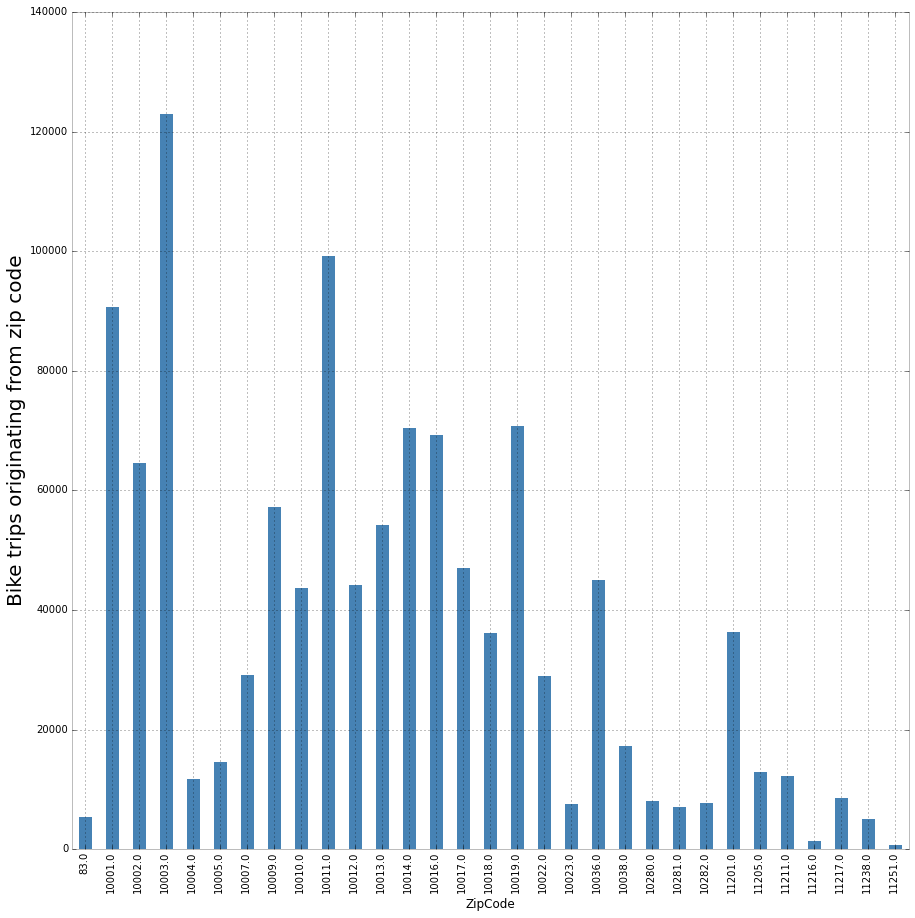

In [35]:
fig=pl.figure(figsize(15,15))

tripbyzip = (df['start station id'].groupby(df['ZipCode']).count())
tripbyzip.plot(kind='bar')
tripbyzip.head()
pl.ylabel("Bike trips originating from zip code", fontsize=20)

#print (tripbyzip[10001], len(tripbyzip))
#print (tripbyzip)
#it is really annoying that the zips get printed as floats in the axis label

In [13]:
#there is a zip code 83. it looks like it got associated to a few rides. i can remove it
#but i will not need to if there are no zip codes 83 in the building files

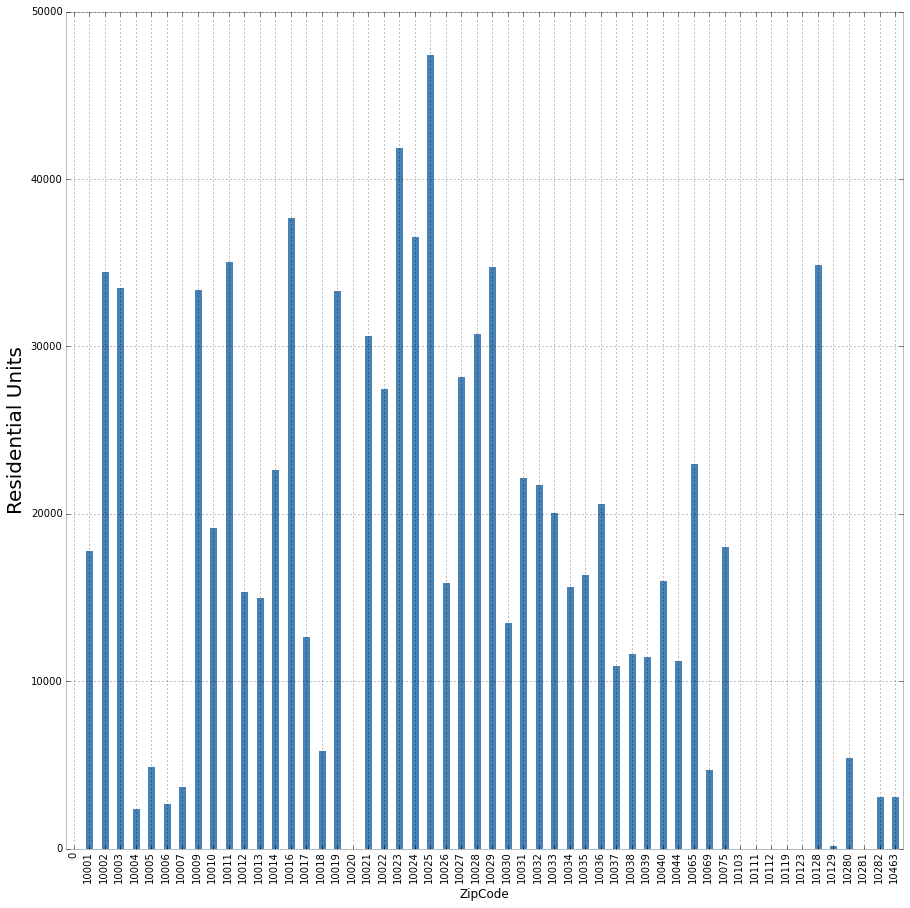

In [36]:
fig = pl.figure(figsize(15,15))
unitsbyzip = (bsize['UnitsRes'].groupby(bsize['ZipCode']).sum())
unitsbyzip.plot(kind='bar')
#print (unitsbyzip[10001], len(unitsbyzip))
#print (unitsbyzip)
unitsbyzip.head()
pl.ylabel("Residential Units", fontsize = 20)


In [15]:
#there is a zip code 0. but it has 0 units and ther eis no zipcode 0 in 
#the other df, so i do not need to worry about 83 or 0

In [16]:
#many ways to do this merge. here is one: since with this setup i have 2 series indexed on ZipCode
#i can concatenate them on axis 1
rides2units = pd.concat([unitsbyzip, tripbyzip], axis=1)

#if i had set up the df's with zipcode as a column i could have used merged instead
#if all else failed i could have run a for loop, which would have looked something like this:
'''
rides2units = []
for k in tripbyzip.keys():
    try: rides2units.append((unitsbyzip[k], tripbyzip[k]))
    except: pass
rides2units = np.array(rides2units)
print (rides2units)
'''

#i am about to save myself some typing by renaming columns
rides2units.rename(columns = {'UnitsRes':'x','start station id':'y'}, inplace=True)
#because there are not many datapoints i can print all nonnull ones
print (rides2units[rides2units.y.notnull() & rides2units.x.notnull()])
# i am not worrying about NaN's
#the zipcode with - units is in fact an entirely fanantial-business block with 0 residents. 
#http://www.zip-codes.com/zip-code/10281/zip-code-10281.asp

             x       y
ZipCode               
10001    17866   90926
10002    34498   64764
10003    33560  123117
10004     2413   11907
10005     4955   14694
10007     3717   29222
10009    33427   57402
10010    19215   43865
10011    35101   99453
10012    15399   44322
10013    15047   54442
10014    22656   70676
10016    37738   69428
10017    12711   47203
10018     5909   36387
10019    33348   70873
10022    27543   29065
10023    41894    7663
10036    20659   45241
10038    11663   17448
10280     5474    8178
10281        0    7211
10282     3157    7952


##fitting the data with a first and second degree polynomial

In [17]:
#if i do this i cen plot the cirve fit easily witout ugly lines joining the datapoints
rides2units = rides2units.sort('x')

result1deg = sm.ols(formula = 'y ~ x + I((x))', data=rides2units).fit()
print (result1deg.summary())
result2deg = sm.ols(formula = 'y ~ x + I((x)) + I ((x)**2)', data=rides2units).fit()
print (result2deg.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.365
Model:                            OLS   Adj. R-squared:                  0.335
Method:                 Least Squares   F-statistic:                     12.06
Date:                Thu, 29 Oct 2015   Prob (F-statistic):            0.00227
Time:                        16:24:47   Log-Likelihood:                -265.55
No. Observations:                  23   AIC:                             535.1
Df Residuals:                      21   BIC:                             537.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [95.0% Conf. Int.]
------------------------------------------------------------------------------
Intercept   1.796e+04   9676.859      1.856      0.0

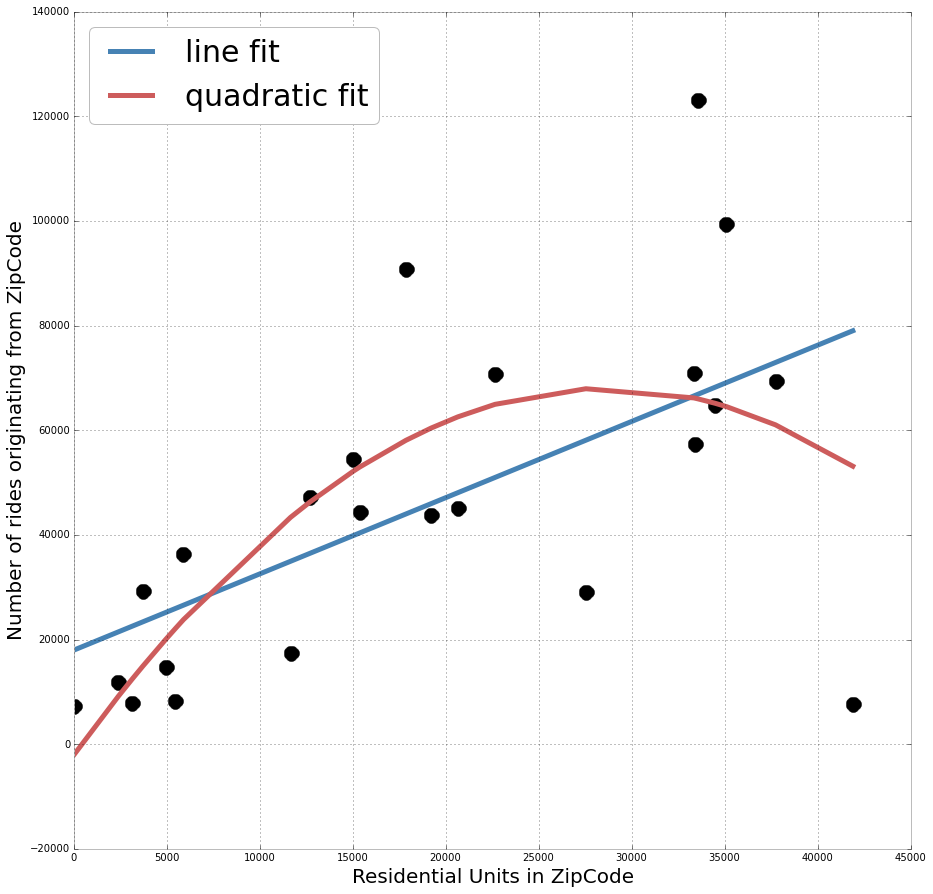

In [18]:
pl.figure(figsize=(15,15))
pl.plot(rides2units.x, rides2units.y, 'k.', markersize=30)
pl.plot(rides2units.x[rides2units.y.notnull() & rides2units.x.notnull() ], 
        result1deg.predict(), lw = 5, label="line fit")
pl.plot(rides2units.x[rides2units.y.notnull() & rides2units.x.notnull() ],
        result2deg.predict(), lw = 5, label="quadratic fit")
pl.xlabel("Residential Units in ZipCode", fontsize=20)
pl.ylabel("Number of rides originating from ZipCode", fontsize=20)
pl.legend(fontsize=30, loc=2)

CAPTION: Rides per residential units: although an upword trend is visible, the data has significant scatter. The line fit seems to describe the data for small number of units, but the spread on the y-axis increases at the high units end. 
The line fit explains less then 40% of the variance in the data (adjusted R^2) and the 2nd degree polynomial less then 50%.  A single datapoint between 40000 and 45000 units is distant from the core of the distribution and drags the fit to lower values at high units numbers, which drives the shape of the curve fit. 
Notice that there are less then 25 datapoints: the dataset is not large. Small datasets are always an issue, but also because the dataset is small nearly any technuque more sophysticated then a simple fit is non applicable: the low number of datapoints limits the number of parameters we can afford to introduce, and the number of features we can use. 

#I will perform a Likelihood ratio test to see which fit is better. For this test the NULL hypothesis is that the simpler model, the line fit, is a better fit to the data.

In [37]:
lr =  -2*(result1deg.llf-result2deg.llf )

print ("lr = ", lr)

lr =  5.39948646763


##the number of degrees of freedom for this model is the difference between the number of dof's for the line and 2d polynomial fit: 
##DF = 1
##at $\alpha$=0.05 the $\chi^2$ distribution takes a value of 3.84 P(3.84)>P(5.38)

#at a p-value 0.05 the 2nd degree polynomial fit is better then a line fit.

#Removing outliers may change the fits. 
##the High residential units Low rides datapoint I identified in the previoius plot is likely to drive the shape of the fits: it has a large leverage. It may be an outlier 

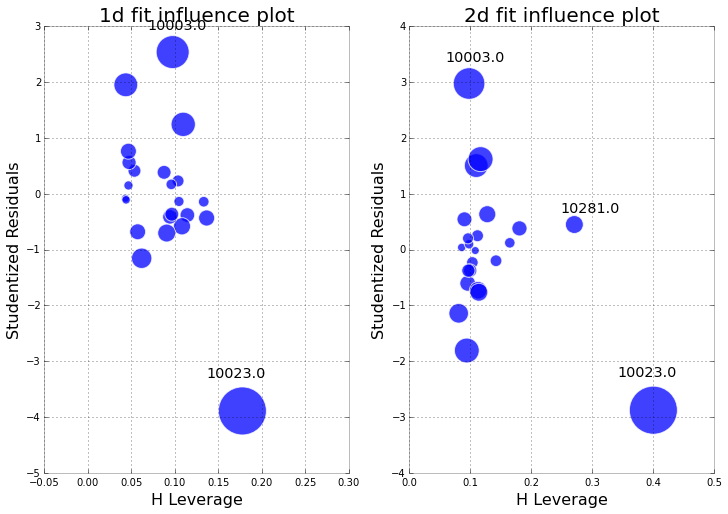

In [38]:
fig = pl.figure(figsize=(12,8))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
sm1.graphics.influence_plot(result1deg, ax=ax1, criterion="cooks")
sm1.graphics.influence_plot(result2deg, ax=ax2, criterion="cooks")
ax1.set_title("1d fit influence plot", fontsize=20)
ax2.set_title("2d fit influence plot", fontsize=20)

CAPTION: this is an influence plot: the size of the datapoints represents the influence it has on the fit.
        The plot on the left panel is for the line fit, on the right panel for the 2nd degree polynomial, but the highest leverage points are the same in both plots. An obvious point worth investigation is the point with 10023.0 rides, which by inspecting my list of data by eye, since it is a short liet, i identify as the point on the bottom right of the previous plot, as expected. 

In [39]:
#I am going to remove very low and very high residential units zips. 
#Very low are in the finantial district. They are outlier if I want to infer about 
#the rest of the city.
#Very high may be the lower east side.
#Even if they were not strictly outlier it makesd sense to remove them to generate a solid 
#prediction for the areas that have a more "normal" population

In [40]:
rides2units_cut = rides2units[(rides2units.x<40000) & (rides2units.x>1000)].sort('x')

result1deg_cut = sm.ols(formula = 'y ~ x + I((x))', data=rides2units_cut).fit()
print (result1deg_cut.summary())
result2deg_cut = sm.ols(formula = 'y ~ x + I((x)) + I ((x)**2)', data=rides2units_cut).fit()
print (result2deg_cut.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.580
Model:                            OLS   Adj. R-squared:                  0.558
Method:                 Least Squares   F-statistic:                     26.26
Date:                Thu, 29 Oct 2015   Prob (F-statistic):           6.03e-05
Time:                        16:48:36   Log-Likelihood:                -237.46
No. Observations:                  21   AIC:                             478.9
Df Residuals:                      19   BIC:                             481.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [95.0% Conf. Int.]
------------------------------------------------------------------------------
Intercept   1.281e+04   8445.026      1.517      0.1

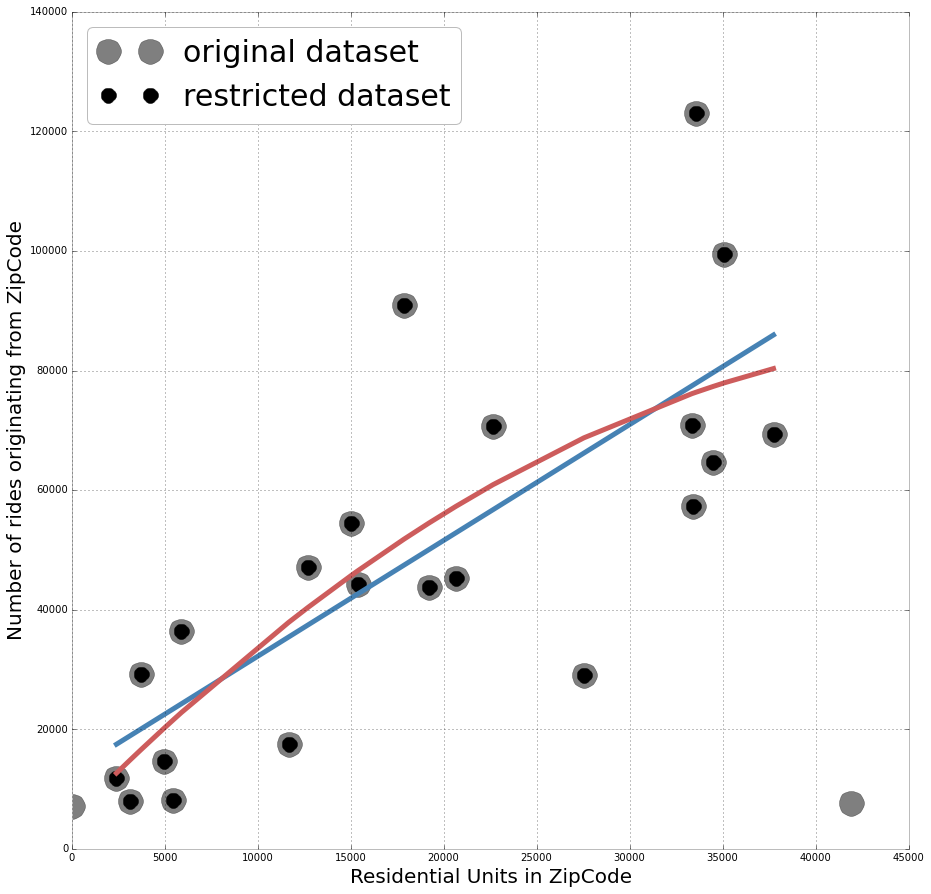

In [41]:
pl.figure(figsize=(15,15))
pl.plot(rides2units.x, rides2units.y, 'k.', markersize=50, alpha=0.5, label="original dataset")
pl.plot(rides2units_cut.x, rides2units_cut.y, 'k.', markersize=30, label="restricted dataset")
pl.plot(rides2units_cut.x[rides2units_cut.y.notnull() & rides2units_cut.x.notnull() ], 
        result1deg_cut.predict(), lw=5)
pl.plot(rides2units_cut.x[rides2units_cut.y.notnull() & rides2units_cut.x.notnull() ], 
        result2deg_cut.predict(), '-', lw=5)
pl.xlabel("Residential Units in ZipCode", fontsize=20)
pl.ylabel("Number of rides originating from ZipCode", fontsize=20)
pl.legend(fontsize=30, loc=2)

CAPTION: Rides per residential units with the restricted dataset after removal of very high and very low residential units ZipCodes: removing high influence points changed the shape if the fits significantly, especially for the 2nd degree polynomial, which now looks much closer to a straignt line

In [42]:
lr =  -2*(result1deg_cut.llf-result2deg_cut.llf )

print ("lr = ", lr)

lr =  0.626881236228


removing high influence points change the relative likelihood of the fits dramatically: 

DF = 1 => at $\alpha$=0.05 P_$\chi^2_{1\mathrm{DOF}}$(3.84) > P_$\chi^2_{1\mathrm{DOF}}(0.6)

at a p-value 0.05 the second polynomial fit is WORSE then a line fit

#The linear model explains >=55% (adjusted $R^2$) of the variability in the data after removing what were classified as "outliers" (~30% before). While this is not a great fit, 50% is a reasonably good value for predictions involving human behavior, and it certainly establishes the presence of an increasing trend in the number of rides with residential units. 
##This data could be augmented with the data from Brooklyn, which is a more properly residential area then Manhattan. However Brooklyn has fewer bike hubs (Notice that while the analysis of the Brooklyn data separately would be crippled by the low number of datapoints, there is no guarantee that the two area would behave in a comparable fashion, since they are inherently different by socioechonomic factors and residential fraction. Either choice has downfalls)

##I speculate that the first improvement to this analysis would be the introduction of a normalization factor that accounts for the availability of citibikes, as well as the availability of alternative means of transportation.